# 06 — Topic Review & Refinement

Now that NB 02 discovers topics data-driven (no predefined keywords), this notebook
helps you **review and iteratively improve** the topic model:

1. Inspect topic quality metrics (coherence, size distribution)
2. Find articles that are ambiguously assigned (multi-topic)
3. Check for any remaining 'noise' articles and characterise them
4. Optionally re-run NB 02 with adjusted hyperparameters

Input : `data/classified_articles.csv`, `data/topic_info.csv`  
No new output files — this is a diagnostic/review notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

df_all = pd.read_csv('data/classified_articles.csv', parse_dates=['date'])
topic_info = pd.read_csv('data/topic_info.csv')

if 'primary_topic' not in df_all.columns:
    df_all['primary_topic'] = 'other'
if 'risk_score' not in df_all.columns:
    df_all['risk_score'] = 0

print(f'Total rows (article × subtopic): {len(df_all):,}')
print(f'Unique articles   : {df_all["id"].nunique():,}')
print(f'Unique subtopics  : {df_all["subtopic"].nunique()}')
print(f'Primary topics    : {df_all["primary_topic"].nunique()}')

df_all['subtopic'].value_counts()

Total rows (article × subtopic): 103,343
Unique articles   : 37,259
Unique subtopics  : 23
Primary topics    : 17


subtopic
Middle East Conflict                 24263
Venezuela Politics & Oil              6470
Russia-Ukraine War                    6238
Australian War Crimes Case            5464
Oil & Fuel Prices                     5438
Cybersecurity & Data Breaches         5048
Retail Prices & Inflation             4677
Education & Student Loans             4581
Crime & Policing                      4085
Weather & Climate                     3810
Myanmar & Bangladesh Politics         3788
French Politics                       3772
China & Taiwan                        3757
AI & OpenAI                           3278
Electric Vehicles & Auto Industry     2767
Vaccines & RFK Jr                     2636
Farming & Inheritance Tax             2627
Airlines & Flights                    2430
Water Utilities & Sewage              2102
Amazon Rainforest & Drought           2047
Marine Ecosystems                     1627
Biodiversity & Wildlife               1590
Vatican & Papacy                       848
Na

## 1 — Topic Size Distribution

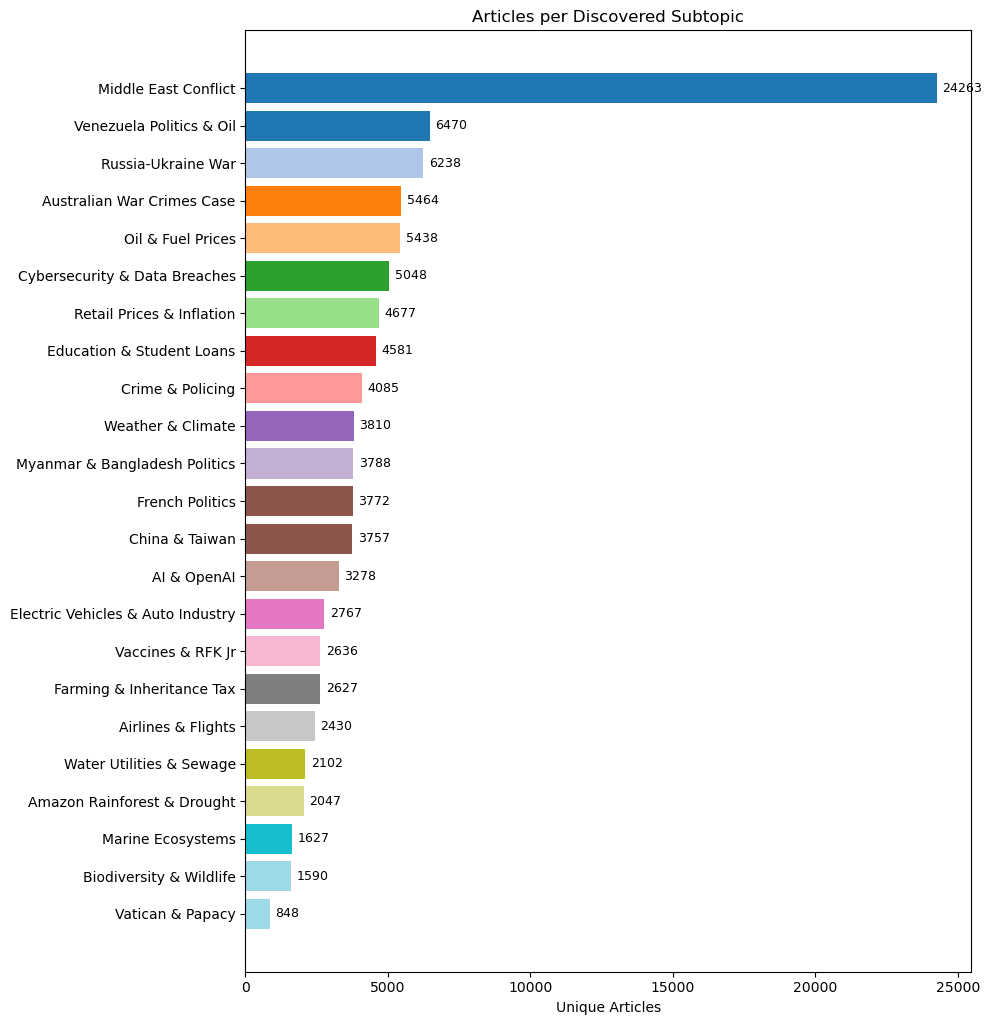


Topic keywords (from BERTopic):
  Middle East Conflict            → ['gaza', 'israel', 'israeli', 'iran', 'donald trump', 'trumps', 'president', 'hamas', 'bank', 'party', 'labour', 'inflation']
  Russia-Ukraine War              → ['ukraine', 'russian', 'russia', 'ukrainian', 'zelenskyy', 'putin', 'ukraine war', 'kyiv', 'ukraines', 'president', 'volodymyr', 'war briefing']
  AI & OpenAI                     → ['ai', 'artificial', 'artificial intelligence', 'intelligence', 'chatgpt', 'openai', 'technology', 'company', 'tech', 'media', 'chatbot', 'google']
  Weather & Climate               → ['weather', 'temperatures', 'flooding', 'rain', 'heatwave', 'floods', 'climate', 'heat', 'flood', 'storm', 'parts', 'extreme']
  Retail Prices & Inflation       → ['sales', 'retail', 'food', 'prices', 'price', 'retailers', 'shoppers', 'inflation', 'supermarket', 'grocery', 'chain', 'stores']
  Venezuela Politics & Oil        → ['venezuela', 'maduro', 'nicols', 'president', 'nicols maduro', 'venezuelas

In [2]:
# Unique articles per subtopic (deduplicated)
dist = (
    df_all.drop_duplicates(subset=['id', 'subtopic'])
    .groupby('subtopic')['id'].count()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, max(4, len(dist) * 0.45)))
colors = cm.tab20(np.linspace(0, 1, len(dist)))
bars = ax.barh(dist.index[::-1], dist.values[::-1], color=colors[::-1])
ax.bar_label(bars, fmt='%d', padding=4, fontsize=9)
ax.set_xlabel('Unique Articles')
ax.set_title('Articles per Discovered Subtopic')
plt.tight_layout()
plt.savefig('data/topic_size_distribution.png', dpi=150)
plt.show()

print('\nTopic keywords (from BERTopic):')
for _, row in topic_info.iterrows():
    print(f"  {row['subtopic_name']:30s}  → {row['Representation']}")

## 2 — Multi-Label Distribution
How many topics does each article get assigned to?

Labels per article:
subtopic
1     2857
2     2720
3    31682

Mean labels/article: 2.77


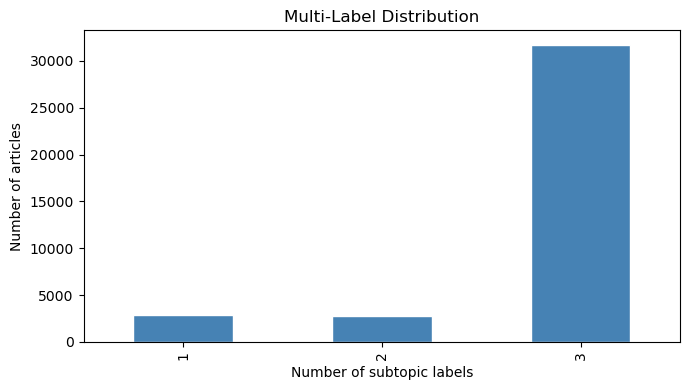

In [3]:
label_counts = df_all.groupby('id')['subtopic'].nunique()
print('Labels per article:')
print(label_counts.value_counts().sort_index().to_string())
print(f'\nMean labels/article: {label_counts.mean():.2f}')

fig, ax = plt.subplots(figsize=(7, 4))
label_counts.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of subtopic labels')
ax.set_ylabel('Number of articles')
ax.set_title('Multi-Label Distribution')
plt.tight_layout()
plt.show()

## 3 — Topic Overlap Heatmap
For multi-label articles, which topic pairs co-occur most often?

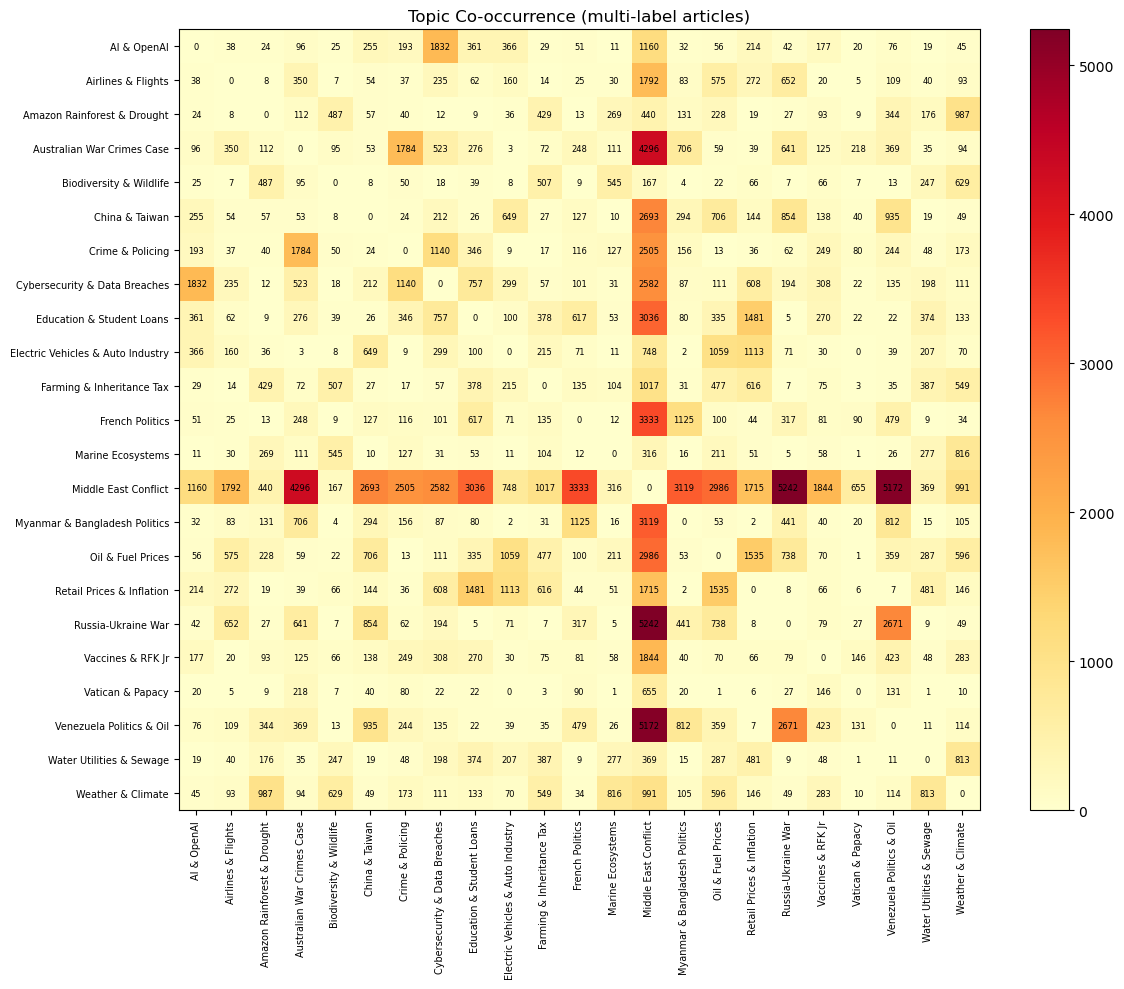

Saved: data/topic_cooccurrence.png


In [5]:
from itertools import combinations

# Build co-occurrence matrix
multi = df_all.groupby('id')['subtopic'].apply(list)
topics_list = sorted(df_all['subtopic'].unique())
co = pd.DataFrame(0, index=topics_list, columns=topics_list)

for labels in multi:
    unique_labels = list(set(labels))
    for a, b in combinations(unique_labels, 2):
        co.loc[a, b] += 1
        co.loc[b, a] += 1

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(co.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(co.columns)))
ax.set_xticklabels(co.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(co.index)))
ax.set_yticklabels(co.index, fontsize=7)
for i in range(co.shape[0]):
    for j in range(co.shape[1]):
        ax.text(j, i, int(co.iat[i, j]), ha='center', va='center', fontsize=6)
fig.colorbar(im, ax=ax)
ax.set_title('Topic Co-occurrence (multi-label articles)', fontsize=12)
plt.tight_layout()
plt.savefig('data/topic_cooccurrence.png', dpi=150)
plt.show()
print('Saved: data/topic_cooccurrence.png')

## 4 — Sample Headlines per Topic
Verify each topic makes sense by reading real headlines.

In [ ]:
N_SAMPLE = 6  # headlines to show per topic
for topic_name, grp in df_all.groupby('subtopic'):
    unique_arts = grp.drop_duplicates('id')
    sample = unique_arts['headline'].sample(
        min(N_SAMPLE, len(unique_arts)), random_state=42
    )
    print(f'\n─── {topic_name} ({len(unique_arts):,} articles) ───')
    for h in sample:
        print(f'  • {h}')


─── AI & OpenAI (3,278 articles) ───
  • ‘A lot of fun’: will Trump’s rambling Joe Rogan interview rally young men?
  • Students give English HSC exam an F over use of image with ‘hallmarks’ of AI
  • Apple reports massive spike in iPhone revenue, particularly in China
  • If AI makes human labor obsolete, who decides who gets to eat?
  • Pocock says politicians using encrypted messaging apps damages ‘health of our democracy’
  • Tech shares slide after SoftBank sells Nvidia stake; UK interest rate cut expected in December – as it happened

─── Airlines & Flights (2,430 articles) ───
  • FTSE 100 ends day at closing high after gold and silver fell in ‘metals meltdown’ – as it happened
  • Red Cross and Foreign Office to discuss plan to visit Palestinians in Israeli detention
  • Australia cancels visa of Jewish influencer who previously called for Islam to be banned 
  • Government’s deal with Iraq to return illegal migrants will ‘deter small boat arrivals’, says Starmer – as it happe

## 5 — Tuning Guidance

If results aren't right, adjust these in NB 02 and re-run NB 02 → 03 → 04 → 05:

| Problem | Fix in NB 02 |
|---|---|
| Too few topics (< 10) | Lower `MIN_CLUSTER_SIZE` (e.g. `len(df) // 300`) |
| Too many topics (> 20) | Raise `MIN_CLUSTER_SIZE` or set `NR_TOPICS = 15` |
| Topics look too similar | Set `NR_TOPICS = 'auto'` or a lower integer to force merging |
| Too many articles get 2–3 labels | Raise `SIMILARITY_THRESHOLD` (e.g. 0.40) |
| Too many articles stuck at 1 label | Lower `SIMILARITY_THRESHOLD` (e.g. 0.22) |
| A topic is clearly noise | Map its `topic_id → None` in `TOPIC_NAME_MAP` |
| Two topics should merge | Give them the same name in `TOPIC_NAME_MAP` |

In [7]:
# Handy: show articles assigned to ONLY one topic that might be noise
# (high-confidence single assignment — inspect the bottom-ranked topics)
small_topics = dist[dist < 100].index.tolist()
if small_topics:
    print(f'Topics with < 100 articles (consider merging or discarding): {small_topics}')
    for t in small_topics:
        grp = df_all[df_all['subtopic'] == t].drop_duplicates('id')
        print(f'\n  [{t}]')
        for h in grp['headline'].head(5):
            print(f'    • {h}')
else:
    print('All topics have ≥ 100 articles. Distribution looks healthy.')

All topics have ≥ 100 articles. Distribution looks healthy.


## Step 7 — Audit `primary_topic` and cluster `other` candidates

This section helps expand your taxonomy over time. It finds high-frequency terms in articles tagged `primary_topic == 'other'` (if any), so you can promote them into new keyword groups in notebook 01.

In [8]:
import re
from collections import Counter

STOPWORDS = {
    'the','and','for','with','that','this','from','have','will','said','says','into','about','after','before',
    'more','than','over','under','into','onto','their','there','where','when','what','which','while','could',
    'would','should','also','been','were','they','them','then','your','just','because','through','against',
    'news','guardian','analysis','report','reports'
}

print('Primary topic distribution (unique articles):')
pt_dist = (
    df_all[['id', 'primary_topic']]
      .drop_duplicates('id')
      .groupby('primary_topic')['id']
      .count()
      .sort_values(ascending=False)
)
print(pt_dist.to_string())

other_df = df_all[df_all['primary_topic'].fillna('other') == 'other'].drop_duplicates('id').copy()
print(f"\n'other' unique articles: {len(other_df):,}")

if len(other_df) == 0:
    print('No "other" articles currently. Taxonomy coverage is good.')
else:
    text = (other_df['headline'].fillna('') + ' ' + other_df['body'].fillna('').str[:600]).str.lower()
    tokens = []
    for t in text:
        words = re.findall(r"[a-z][a-z\-]{2,}", t)
        words = [w for w in words if w not in STOPWORDS and not w.isdigit()]
        tokens.extend(words)

    top_terms = Counter(tokens).most_common(40)
    print('\nTop candidate terms inside "other":')
    for term, cnt in top_terms:
        print(f'  {term:20s} {cnt:>5d}')

    print('\nSample high-risk "other" headlines:')
    if 'risk_score' in other_df.columns:
        sample = other_df.sort_values('risk_score', ascending=False).head(12)
    else:
        sample = other_df.head(12)
    for h in sample['headline'].tolist():
        print(f'  - {h}')

Primary topic distribution (unique articles):
primary_topic
geopolitics_conflict    26024
ai                       3772
public_health            3462
macroeconomy             1371
climate_weather          1114
energy_markets            977
elections_governance      393
trade_industry             67
supply_chain               40
commodities_metals         12
cybersecurity               7
defense_security            5
labor_social                5
food_water_security         4
natural_disasters           3
finance_banking             2
technology_policy           1

'other' unique articles: 0
No "other" articles currently. Taxonomy coverage is good.
